# Markov Decision Process (MDP)

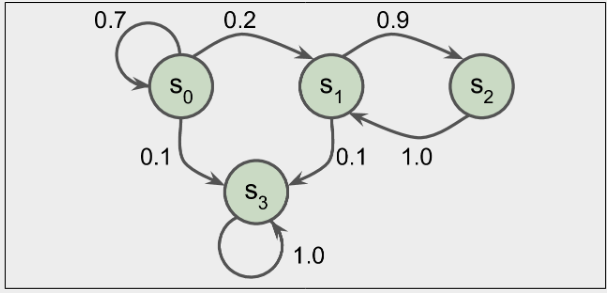

Sample Markov Chain with 4 states ($S_0$ to $S_3$) with their transition probabilities.

A Markov chain is a mathematical model for a system that moves between states with certain probabilities, where the future depends **only** on the present state, not on the past history. This is called the **Markov property**.

### Key ideas

- **States**: A finite or countable set of states $( S = \{s_0, s_1, \dots\} )$.
- **Transition probabilities**: For each pair of states $(i, j)$, a probability
  $[
  P_{ij} = \Pr(X_{t+1} = j \mid X_{t} = i),
  ]$
  collected in a **transition matrix** $(P)$.

- **Memoryless (Markov property)**:
  $[
  \Pr(X_{t+1} = j \mid X_t = i, X_{t-1}, \dots, X_0)
  = \Pr(X_{t+1} = j \mid X_t = i).
  ]$

- **State distribution evolution**: If $(Pi_t)$ is a row vector of state probabilities at time $(t)$, then
  $[
  Pi_{t+1} = Pi_t P.
  ]$

Markov chains are used to model random processes over time, such as web page navigation, queues, weather, and many other stochastic systems.

<div align="center">
<strong>Bellman Optimality Equation</strong>

$$
V^{*}(s) \;=\; \max_{a}\; \sum_{s'} T(s,a,s')\bigl[R(s,a,s') + \gamma\,V^{*}(s')\bigr]
\qquad\text{for all } s
$$
</div>

The Bellman Optimality Equation provides a recursive relationship for the optimal state-value function $(V^*(s))$ in a Markov Decision Process (MDP). It states that the optimal value of a state is equal to the maximum expected return achievable by taking any action from that state, considering both immediate rewards and future discounted rewards.

<div align="center">
<strong>Value Iteration Algorithm</strong>
$$
V_{k+1}(s)\;\leftarrow\;\max_{a}\;\sum_{s'} T(s,a,s')\bigl[\,R(s,a,s') + \gamma\,V_{k}(s')\,\bigr]
\qquad\text{for all } s
$$
</div>

The value iteration algorithm is an iterative method used to compute the optimal state-value function $(V^*(s))$ in a Markov Decision Process (MDP). It repeatedly updates the value of each state by considering the maximum expected return from all possible actions, taking into account both immediate rewards and future discounted rewards, until convergence.

In [6]:
import numpy as np

# Implementation of Value Iteration Algorithm
def value_iteration(transitions, rewards, gamma=0.9, tolerance=1e-8, max_iterations=10_000):
    num_states = transitions.shape[0]
    V = np.zeros(num_states, dtype=float)
    for _ in range(max_iterations):
        V_prev = V.copy()
        action_returns = np.sum(transitions * (rewards + gamma * V_prev), axis=2)
        V = np.max(action_returns, axis=1)
        if np.max(np.abs(V - V_prev)) < tolerance:
            break
    return V

In [7]:
test_transitions = np.array([
    [[0.5, 0.5, 0.0], [0.0, 1.0, 0.0]],
    [[0.0, 0.4, 0.6], [0.2, 0.0, 0.8]],
    [[0.1, 0.0, 0.9], [0.0, 0.0, 1.0]],
], dtype=float)
test_rewards = np.array([
    [[5, 2, 0], [0, 3, 0]],
    [[0, 1, 4], [2, 0, 6]],
    [[0, 0, 8], [0, 0, 0]],
], dtype=float)

gamma = 0.9 # discount factor
V_star = value_iteration(test_transitions, test_rewards, gamma)
print("Optimal state values:", np.round(V_star, 3))

Optimal state values: [60.702 64.113 66.648]


<div align="center">
<strong>Q-Value Iteration Algorithm</strong>
$$
Q_{k+1}(s,a)\;\leftarrow\;\sum_{s'} T(s,a,s')\bigl[\,R(s,a,s') + \gamma\,\max_{a'} Q_{k}(s',a')\,\bigr]
\qquad\text{for all } s,a
$$
</div>

The Q-Value Iteration Algorithm is an iterative method used to compute the optimal action-value function $(Q^*(s,a))$ in a Markov Decision Process (MDP). It updates the Q-values for each state-action pair by considering the expected return from taking that action, which includes both immediate rewards and the maximum future discounted rewards obtainable from the next state, until convergence.

### Example MDP
- 3 states: S = {0, 1, 2}
- 3 actions: A = {0, 1, 2}
- Transition probabilities T(s, a, s')
- Rewards R(s, a, s')
- Discount factor γ = 0.90
- Goal: Compute optimal Q-values using Q-Value Iteration

In [8]:
def q_value_iteration(transitions, rewards, gamma=0.9, tolerance=1e-8, max_iterations=10_000):
    num_states, num_actions, _ = transitions.shape
    Q = np.zeros((num_states, num_actions), dtype=float)

    for _ in range(max_iterations):
        Q_prev = Q.copy()
        next_state_values = np.max(Q_prev, axis=1)
        expected_returns = np.sum(
            transitions * (rewards + gamma * next_state_values[np.newaxis, np.newaxis, :]),
            axis=2,
        )
        Q = expected_returns
        if np.max(np.abs(Q - Q_prev)) < tolerance:
            break
    return Q

In [9]:
Q_values = q_value_iteration(test_transitions, test_rewards, gamma)

In [10]:
print("Optimal Q-values:\n", np.round(Q_values, 3))

Optimal Q-values:
 [[59.667 60.702]
 [61.871 64.113]
 [66.648 59.983]]


### Cartpole (Sample MDP Environment)

In [11]:
import gymnasium as gym

# Create the CartPole environment
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [12]:
# Reset the environment to start a new episode
observation = env.reset()

observation

(array([ 0.01996977,  0.02149229, -0.02232877, -0.0011847 ], dtype=float32),
 {})

In [13]:
# Shows the number of possible actions
env.action_space

Discrete(2)

In [14]:
action = 0 # Actions: 0 (push left), 1 (push right)

In [15]:
observation = env.step(action)

reward = observation[1]
terminated = observation[2]
truncated = observation[3]
info = observation[4]

In [16]:
observation[0], reward, terminated, truncated, info

(array([ 0.02039962, -0.17330243, -0.02235247,  0.28437045], dtype=float32),
 1.0,
 False,
 False,
 {})

In [17]:
def basic_policy(obs):
    """A basic policy that pushes the cart in the direction of the pole's tilt."""
    angle = obs[2]  # Pole angle
    return 0 if angle < 0 else 1  # 0: left, 1: right

In [18]:
totals = []
for episode in range(500):
    episode_reward = 0
    obs = env.reset()
    for step in range(200):
        action = basic_policy(obs[0])
        obs = env.step(action)
        episode_reward += obs[1]
        if obs[2] or obs[3]:  # terminated or truncated
            break
    totals.append(episode_reward)

In [19]:
import numpy as np

np.mean(totals), np.std(totals), np.min(totals), np.max(totals)

(np.float64(41.778),
 np.float64(8.85215883273679),
 np.float64(24.0),
 np.float64(72.0))

**Interpretation**:
- The basic policy managed to keep the pole balanced for an average of around 42 time steps per episode.
- The performance varied significantly, with some episodes lasting as few as 24 time steps and others reaching up to 72 time steps.